In [1]:
import networkx as nx
import numpy as np
from itertools import combinations
from sim_tools.distributions import spawn_seeds

In [2]:
class SchoolFriendshipNetwork:

    def __init__(self, n, s, k, p, seed=None):

        # Parameters
        self.n = n
        self.s = s
        self.k = k
        self.p = p

        # Spawn seeds
        self.seeds = spawn_seeds(5, seed)

        # Random number generators
        self.class_binom_rng = np.random.default_rng(self.seeds[0])
        self.class_int_rng = np.random.default_rng(self.seeds[1])
        self.school_binom_rng = np.random.default_rng(self.seeds[2])
        self.school_int_rng = np.random.default_rng(self.seeds[3])
        self.graph_rng = np.random.default_rng(self.seeds[4])

    def generate_class_network(self, n_s):

        # If large enough for there to be subnetworks...
        if n_s - 1 > 4 * self.k:
    
            # Number of subnetworks
            f = (n_s - 1) // (2 * self.k)
            # Min. number of students in each subnetwork
            n_f = n_s // f
            # Probability that any 2 students in the same subnetwork are friends
            p_f = self.k / (n_f - 1)
            
            # Create Erdos-Renyi graphs for each subnetwork
            g_list = []
            for snw in range(n_s % f):
                g_list.append(nx.erdos_renyi_graph(n_f+1, p_f, seed=self.graph_rng))
            for snw in range(n_s % f, n_f):
                g_list.append(nx.erdos_renyi_graph(n_f, p_f, seed=self.graph_rng))
                
            # Merge graphs
            G = g_list[0]
            for snw in range(1,f):
                G = nx.disjoint_union(G, g_list[snw])
    
            # Rewire edges of G
            original_edges = list(G.edges)
            all_edges = list(combinations(list(G.nodes), r=2))
            for edge in original_edges:
                # Randomly rewire with probability p
                if self.class_binom_rng.binomial(1, self.p):
                    G.remove_edge(edge[0], edge[1])
                    poss_edges = list(set(all_edges).difference(list(G.edges)))
                    index = self.class_int_rng.integers(len(poss_edges))
                    new_edge = poss_edges[index]
                    G.add_edge(new_edge[0], new_edge[1])
                    
        # Else no subnetworks and entire class an ER network
        else:
    
            # Probability that any 2 students in the same subnetwork are friends
            p_s = self.k / (n_s - 1)
    
            # Create an Erdos-Renyi graph for the class
            G = nx.erdos_renyi_graph(n_s, p_s)
    
        return G

    def generate_school_network(self):

        # Number of students per class
        n_s = self.n // self.s
    
        # For each class
        g_list = []
        for i in range(self.n % self.s):
            g_list.append(self.generate_class_network(n_s+1))
        for i in range(self.n % self.s, self.s):
            g_list.append(self.generate_class_network(n_s))
    
        # Merge classroom graphs
        G = g_list[0]
        for i in range(1,self.s):
            G = nx.disjoint_union(G, g_list[i])
            
        # Randomly rewire within the entire school
        original_edges = list(G.edges)
        all_edges = list(combinations(list(G.nodes), r=2))
        for edge in original_edges:
            # Randomly rewire with probability p
            if self.school_binom_rng.binomial(1, self.p):
                G.remove_edge(edge[0], edge[1])
                poss_edges = list(set(all_edges).difference(list(G.edges)))
                index = self.school_int_rng.integers(len(poss_edges))
                new_edge = poss_edges[index]
                G.add_edge(new_edge[0], new_edge[1])
    
        # Store graph
        self.network = G

    def plot_network(self):

        nx.draw(self.network)

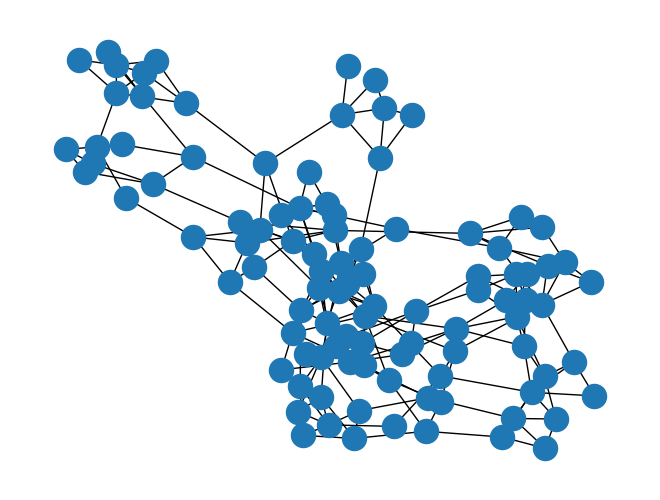

In [3]:
sfn = SchoolFriendshipNetwork(n=100, s=3, k=4, p=0.1, seed=42)
sfn.generate_school_network()
sfn.plot_network()